# Parte 2: Práctica



Importar librerías

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Agregar la imagen

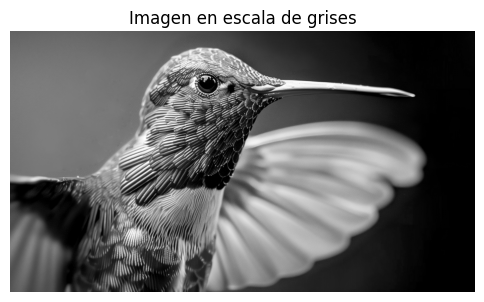

In [ ]:
import urllib.request
#link (copiado de las instrucciones)
url = "https://raw.githubusercontent.com/dilp90/PDI/main/Imagenes/colibri.jpg"

#descarga la imagen al programa
urllib.request.urlretrieve(url, "colibri.jpg")

#lectura de imagen a color
img_color = cv2.imread("colibri.jpg")

#lectura de imagen en escala de grises
img = cv2.imread("colibri.jpg", cv2.IMREAD_GRAYSCALE)

#mostrar imagen en escala de grises
plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.title("Imagen en escala de grises")
plt.axis("off")
plt.show()

## Aplicación de transformaciones

###**Traslación**

Traslación de la imagen

In [ ]:
#mover 170 pixeles a la derecha y 40 hacia abajo
M = np.float32([[1,0,170],
                [0,1,40]])
#los primeros 4 números indica que no hay rotación, cambio en tamaño o deformación
#los últimos 2 números (170 y 40) dice que derecha y abajo respectivamente

#para la traslación se usa una matriz de transformación y la función cv2.warpAffine()
traslacion = cv2.warpAffine(img,M,(img.shape[1], img.shape[0]))

Imagen post-traslación

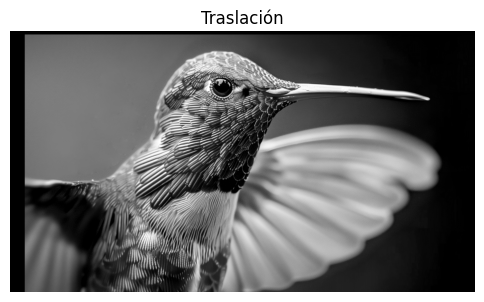

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(traslacion,cmap="gray")
plt.title("Traslación")
plt.axis("off")
plt.show()

###**Escalado**

Cambiar la escalar de la imagen

In [ ]:
escalada = cv2.resize(img,None,fx=2.0,fy=0.7)
#fx es el factor horizontal y fy es el factor vertical

Imagen post-escalada

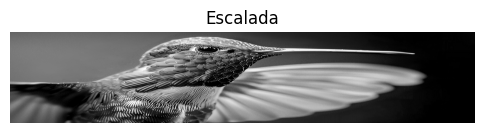

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(escalada,cmap="gray")
plt.title("Escalada")
plt.axis("off")
plt.show()

###**Rotación**

Rotar la imagen

In [ ]:
centroimg = (img.shape[1]//2,img.shape[0]//2)
#filas y columnas /2; calcula las coordenadas dentro de la imagen, [1] es el alto de la imagen, [0] es el ancho, se divide en 2 para que sea el centro
matriz_rotacion = cv2.getRotationMatrix2D(centroimg,35,2)
#cv2.getRotationMatrix2D permite crear una matriz de rotación
#35 es el ángulo de rotación, el 2 es la escala de la imagen
rotada = cv2.warpAffine(img, matriz_rotacion,(img.shape[1],img.shape[0]))
#

Imagen rotada

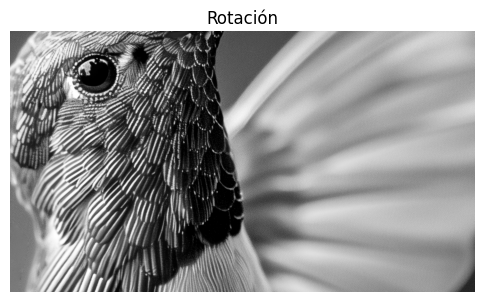

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(rotada,cmap="gray")
plt.title("Rotación")
plt.axis("off")
plt.show()

###**Reflexión**

Hacer una reflexión de la imagen

In [ ]:
reflex = cv2.flip(img,0)
#1 significa horizontal, 0 vertical y -1 ambas

Imagen reflejada

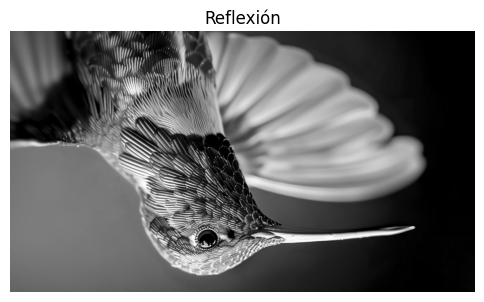

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(reflex,cmap="gray")
plt.title("Reflexión")
plt.axis("off")
plt.show()

Comparación de las imágenes con sus transformaciones

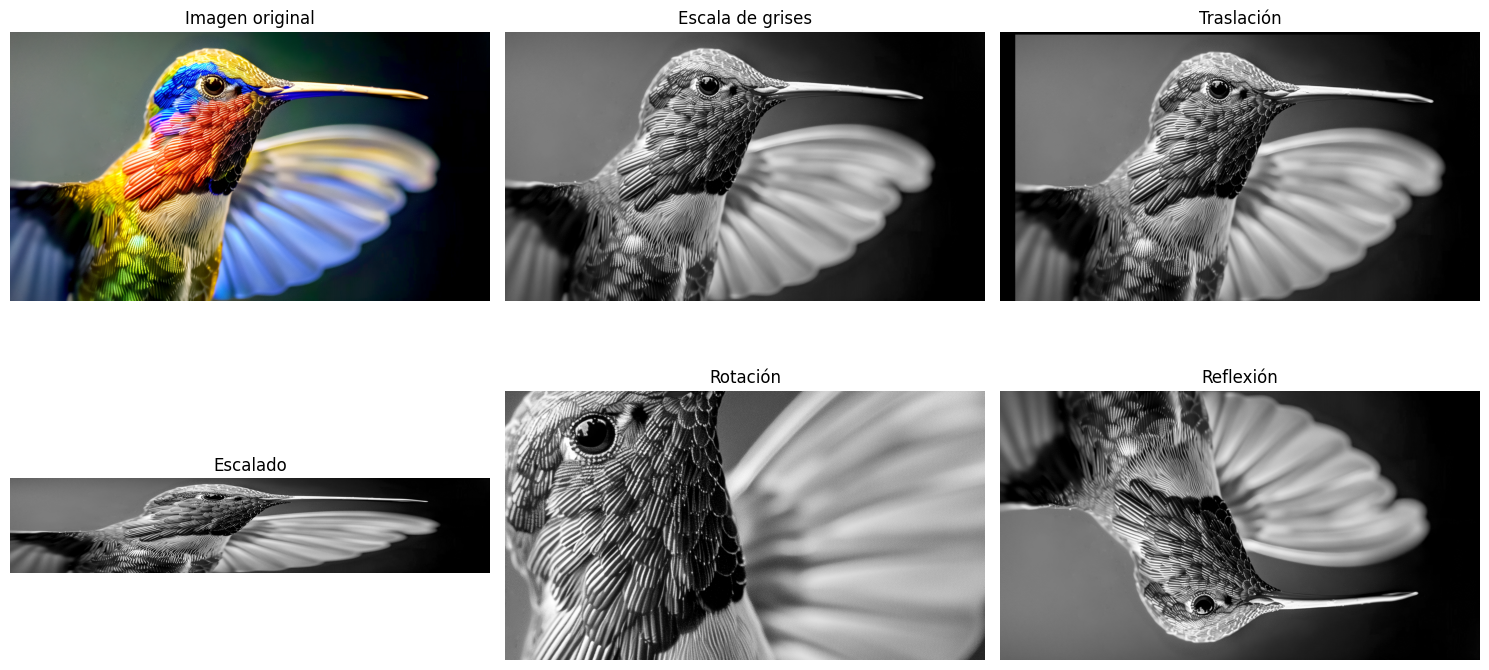

In [ ]:
plt.figure(figsize=(15,8))

#imagen original (la de la tarea)
plt.subplot(2,3,1)
plt.imshow(img_color)
plt.title("Imagen original")
plt.axis("off")

#imagen en escala de grises
plt.subplot(2,3,2)
plt.imshow(img, cmap="gray")
plt.title("Escala de grises")
plt.axis("off")

#traslación
plt.subplot(2,3,3)
plt.imshow(traslacion, cmap="gray")
plt.title("Traslación")
plt.axis("off")

#escalado
plt.subplot(2,3,4)
plt.imshow(escalada, cmap="gray")
plt.title("Escalado")
plt.axis("off")

#rotación
plt.subplot(2,3,5)
plt.imshow(rotada, cmap="gray")
plt.title("Rotación")
plt.axis("off")

#reflexión
plt.subplot(2,3,6)
plt.imshow(reflex, cmap="gray")
plt.title("Reflexión")
plt.axis("off")

plt.tight_layout()
plt.show()

**Comenta el efecto visual de cada transformación**

*   *Imagen original*: se usa como referencia para analizar los cambios después de cada transformación.

*   *Imagen en escala de grises*: convierte la imagen a escala de grises para mantener únicamente la información de la intensidad de cada píxel. Simplifica el procesamiento al utilizar solo 1 canal de información.

*   *Traslación*: mueve la imagen a un nuevo punto sin generar cambio en sus dimensiones, orientación o forma. Con los cambios ahora se generan bordes negros, equivalentes a los espacios que no cuentan con información.

*   *Escalación*: cambia el tamaño de la imagen sin generar cambios en su proporción. Un factor de escala mayor a 1 aumenta el tamaño mientras que un factor menor a 1 disminuye el tamaño de la imagen.

*   *Rotación*: gira la imagen sobre un punto determinado (para esta ocasión, se eligió el centro de la imagen). Las áreas negras en las esquinas son las partes en que la imagen no es visible.

*   *Reflexión*: es una imagen invertida en base a un eje escogido, donde también se pueden escoger dos ejes diferentes.







##**TRANSFORMADA DE FOURIER**

Usar la DFT (discrete fourier transform) permite la transformación de una imagen del dominio espacial al dominio de la frecuencia. Se puede obtener información de las frecuencia en que la mayor parte de la información se encuentra.

In [ ]:
#cambiar la imagen a tipo float32 para cv2.draft
img_float = np.float32(img)

#aplicar la DFT
#cv2.dft() obtiene la tranformada discreta de fourier
dft = cv2.dft(img_float, flags=cv2.DFT_COMPLEX_OUTPUT)
#cv2.dftcomplexoutput especifica que habrá una parte imaginaria y una parte real en el resultado

Centrar las frecuencias obtenidas

In [ ]:
#para centrar las bajas frecuencias para evitar dispersión de información
dft_shift = np.fft.fftshift(dft)

Obtener la magnitud del espectro

In [ ]:
mag = cv2.magnitude(dft_shift[:,:,0],dft_shift[:,:,1])
#magnitud = raíz cuadrada de (resultado real ^2 + resultado imaginario ^2)
# :, :, # significa: filas, columnas, canales

Logaritmo

In [ ]:
# Mejorar la visualización
espectro = np.log(mag + 1)
#se usa el log para reducir el rango de valores y poder visibilizar todas las frecuencias, se le suma 1 para evitar errores porque log (0) no existe

Mostrar resultados

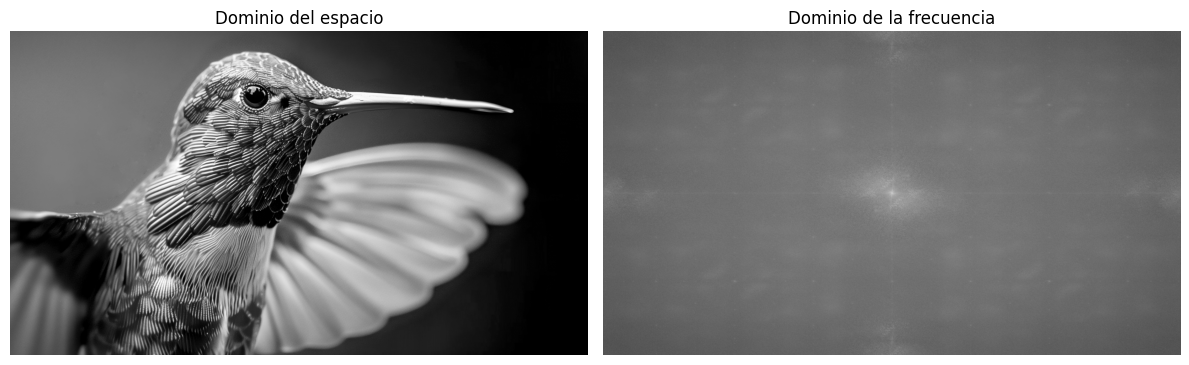

In [ ]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img,cmap="gray")
plt.title("Dominio del espacio")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(espectro,cmap="gray")
plt.title("Dominio de la frecuencia")
plt.axis("off")

plt.tight_layout()
plt.show()

**Interpreta qué tipo de información aparece en el centro y bordes del espectro**

Después de contar con el espectro de frecuencias, se analizó como se distribuye la información en el dominio de la frecuencia. Con esto, las frecuencias bajas están ubicadas en la región del centro, contanto con la información de la iluminación y sus cambios graduales de intensidad. Las altas frecuencias están ubicadas más hacia las orillas, las cuales tienen la información de bordes, texturas y detalles.


**Ejemplo de eliminación de ruido mediante enmascaramiento de frecuencias**

Filtro paso bajo: deja pasar solamente frecuencias bajas cercanas al centro del espectro calculado, con lo que las frecuencias altas no se muestran.

Hacer la máscara

In [ ]:
#dimensiones
filas, columnas = img.shape

#centro del espectro
cen_fila = filas // 2
cen_columna = columnas // 2

#máscara llena de ceros
mascara = np.zeros((filas, columnas, 2), np.uint8)

#radio del filtro paso bajo (cuantas frecuencias bajas pueden pasar por el filtro)
radio = 44

#para que únicamente la info del centro se guarde
mascara[cen_fila-radio:cen_fila+radio,cen_columna-radio:cen_columna+radio] = 1
#el centro de la fila menos el radio: centro de las filas + radio , centro de las columnas - radio: centro de columnas + radio =1
#selecciona una área cuadrada alrededor del espectro de frecuencias y se iguala a 1 a todo lo de esa área, así solo se quedan las frecuencias bajas y las altas quedan como 0

Aplicar el filtro

In [ ]:
fshift = dft_shift * mascara

Regresar al dominio espacial

In [ ]:
#regresar las frecuencias a lo inicial utilizando inverse fast fourier transform shift (iffts)
f_ishift = np.fft.ifftshift(fshift)

#transformada inversa
img_espacial = cv2.idft(f_ishift)
#con esto se vuelve al dominio espacial utilizando la inverse discrete fourier transform (idft)
#magnitud = raíz cuadrada de (resultado real ^2 + resultado imaginario ^2)
# :, :, # significa: filas, columnas, canales
img_espacial = cv2.magnitude(img_espacial[:,:,0],img_espacial[:,:,1])

Mostrar imagen

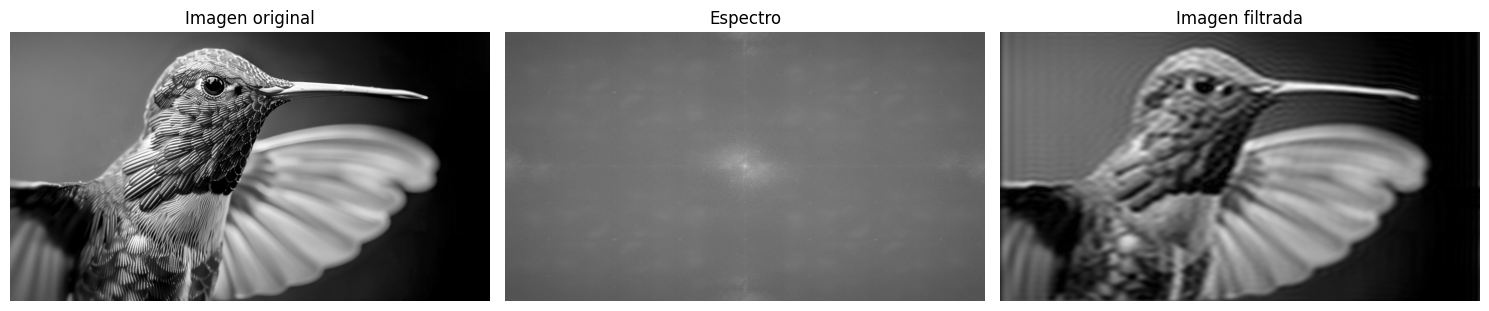

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(espectro, cmap="gray")
plt.title("Espectro")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img_espacial, cmap="gray")
plt.title("Imagen filtrada")
plt.axis("off")

plt.tight_layout()
plt.show()